In [2]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
code_root = project_root / "neuralbi_diff" / "gbi_diff"
code_root = project_root / "neuralbi_diff"
sys.path.extend([str(project_root), str(code_root)])
print(sys.path)

['/home/robin/miniconda3/envs/gbi/lib/python312.zip', '/home/robin/miniconda3/envs/gbi/lib/python3.12', '/home/robin/miniconda3/envs/gbi/lib/python3.12/lib-dynload', '', '/home/robin/miniconda3/envs/gbi/lib/python3.12/site-packages', '/home/robin/projects/lab_project/neuralgbi_diffusion', '/home/robin/projects/lab_project/neuralgbi_diffusion/neuralbi_diff']


In [3]:
import matplotlib.pyplot as plt
from gbi_diff.model.lit_module import Guidance

import matplotlib as mpl
import pandas as pd
from pathlib import Path

colors_tab10 = mpl.colormaps["tab10"]
colors_tab20 = mpl.colormaps["tab20"]


# specify matplotlib rc file
plt.style.use(str(project_root / ".matplotlibrc"))

/home/robin/miniconda3/envs/gbi/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
train_dfs = []
val_dfs = []
for path in Path("../results/train_denoiser").glob("**/csv_logs/metrics.csv"):
    df = pd.read_csv(path)
    dataset_name = path.parent.parent.parent.parent.parent.name
    train_df = df[["epoch", "train/loss"]].dropna()
    train_df = train_df.rename(
        columns={"train/loss": "diffusion" + "/" + dataset_name + "/train/loss"}
    )
    train_dfs.append(train_df)

    val_df = df[["epoch", "val/loss"]].dropna()
    val_df = val_df.rename(
        columns={"val/loss": "diffusion" + "/" + dataset_name + "/val/loss"}
    )
    val_dfs.append(val_df)

for path in Path("../results/train_guidance").glob("**/csv_logs/metrics.csv"):
    df = pd.read_csv(path)
    dataset_name = path.parent.parent.parent.parent.parent.name
    train_df = df[["epoch", "train/loss"]].dropna()
    train_df = train_df.rename(
        columns={"train/loss": "guidance" + "/" + dataset_name + "/train/loss"}
    )
    if "two_moons" in str(path):
        # this was trained by misstake with squared error. scale it to be compatible with other errors
        train_df["guidance" + "/" + dataset_name + "/train/loss"] = train_df["guidance" + "/" + dataset_name + "/train/loss"] / 2
    train_dfs.append(train_df)

    val_df = df[["epoch", "val/loss"]].dropna()
    val_df = val_df.rename(
        columns={"val/loss": "guidance" + "/" + dataset_name + "/val/loss"}
    )
    if "two_moons" in str(path):
        # this was trained by misstake with squared error. scale it to be compatible with other errors
        val_df["guidance" + "/" + dataset_name + "/val/loss"] = val_df["guidance" + "/" + dataset_name + "/val/loss"] / 2
    
    val_dfs.append(val_df)


train_dfs = pd.concat(train_dfs)
val_dfs = pd.concat(val_dfs)

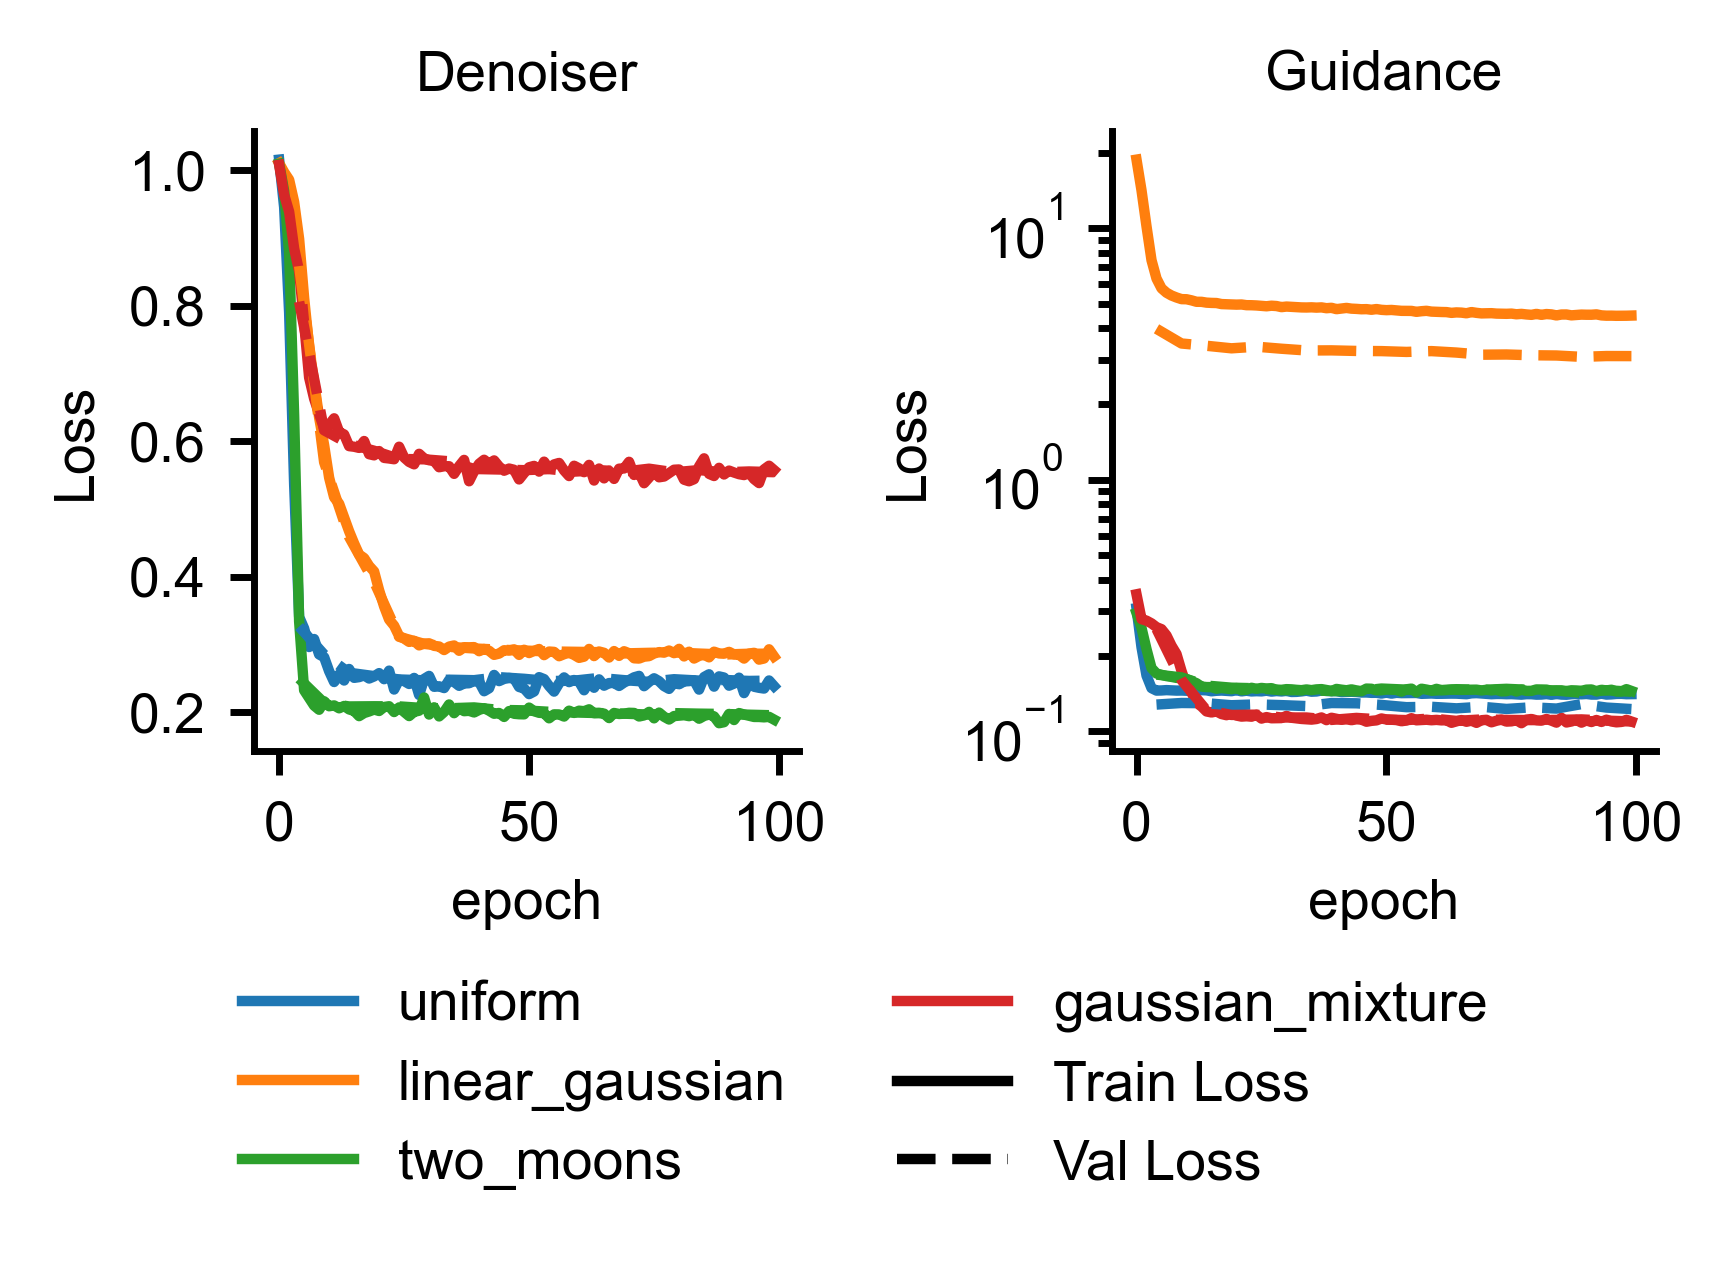

In [8]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(3.5, 2))

labels = ["uniform", "linear_gaussian", "two_moons", "gaussian_mixture"]

column_names = list(map(lambda x: "diffusion/" + x + "/train/loss", labels))
ax = train_dfs.plot(
    "epoch",
    column_names,
    ax=ax1,
    color=[colors_tab10(0), colors_tab10(1), colors_tab10(2), colors_tab10(3)],
    legend=False,
)
handles = ax.get_legend_handles_labels()[0]

column_names = list(map(lambda x: "diffusion/" + x + "/val/loss", labels))
ax = val_dfs.plot(
    "epoch",
    column_names,
    ax=ax1,
    color=[colors_tab10(0), colors_tab10(1), colors_tab10(2), colors_tab10(3)],
    linestyle="--",
    legend=False,
)


column_names = list(map(lambda x: "guidance/" + x + "/train/loss", labels))
ax = train_dfs.plot(
    "epoch",
    column_names,
    ax=ax2,
    color=[colors_tab10(0), colors_tab10(1), colors_tab10(2), colors_tab10(3)],
    legend=False,
)

column_names = list(map(lambda x: "guidance/" + x + "/val/loss", labels))
ax = val_dfs.plot(
    "epoch",
    column_names,
    ax=ax2,
    color=[colors_tab10(0), colors_tab10(1), colors_tab10(2), colors_tab10(3)],
    linestyle="--",
    legend=False,
)


solid_line = plt.Line2D([0], [0], color="k", linestyle="-", label="Train Loss")
dashed_line = plt.Line2D([0], [0], color="k", linestyle="--", label="Val Loss")

ax1.set_ylabel("Loss")
ax2.set_ylabel("Loss")
ax1.set_title("Denoiser")
ax2.set_title("Guidance")

ax2.set_yscale("log")
fig.legend(
    handles + [solid_line, dashed_line],
    labels + ["Train Loss", "Val Loss"],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=2,
)
fig.tight_layout()
fig.savefig("figures/training_curves.pdf")

In [18]:
import numpy as np
import torch
from tqdm import tqdm
from gbi_diff.utils.cast import to_camel_case
from gbi_diff.dataset import dataset as sbi_datasets


def do_eval(dataset_name: str, guidance: Guidance, t: int):
    cls_name = to_camel_case(dataset_name)
    cls_name = cls_name[0].upper() + cls_name[1:]
    dataset_cls = getattr(sbi_datasets, cls_name)
    dataset: sbi_datasets._SBIDataset = dataset_cls.from_file(
        f"../data/{dataset_name}_1000.pt"
    )
    
    losses = []
    time_repr = guidance.get_diff_time_repr(np.ones(1) * 0)
    for batch in tqdm(dataset):
        theta, x, x_target = batch
        with torch.no_grad():
            network_res = guidance.forward(theta[None], x_target[None], time_repr)
            loss = guidance.criterion.forward(network_res, x[None], x_target[None])

        losses.append(loss)
    
    loss = torch.tensor(losses)
    return loss.mean().item(), loss.std().item()

checkpoints = [
    "/home/robin/projects/lab_project/neuralgbi_diffusion/results/train_guidance/gaussian_mixture/2025-03-29-22-02-41/lightning_logs/version_0/epoch=99-step=4000.ckpt",
    "/home/robin/projects/lab_project/neuralgbi_diffusion/results/train_guidance/linear_gaussian/2025-03-29-20-12-56/lightning_logs/version_0/epoch=99-step=4000.ckpt",
    "/home/robin/projects/lab_project/neuralgbi_diffusion/results/train_guidance/two_moons/2025-03-29-19-24-44/lightning_logs/version_0/epoch=94-step=3800.ckpt",
    "/home/robin/projects/lab_project/neuralgbi_diffusion/results/train_guidance/uniform/2025-03-29-19-57-13/lightning_logs/version_0/epoch=99-step=4000.ckpt",
]

keys = ["dataset","parameters", "val/error_mean", "val/error_std"]
df = []
for ckpt in checkpoints:
    ckpt = Path(ckpt)
    dataset_name = ckpt.parent.parent.parent.parent.name
    guidance = Guidance.load_from_checkpoint(ckpt)
    num_params = sum([len(params.flatten()) for params in guidance.parameters()])
    mean, std = do_eval(dataset_name, guidance, 0)
    df.append(dict(zip(keys, [dataset_name, num_params, mean, std])))

df = pd.DataFrame(df)

100%|██████████| 1000/1000 [00:00<00:00, 1395.67it/s]


In [21]:
print(df.to_latex())

\begin{tabular}{llrrr}
\toprule
 & dataset & parameters & val/error_mean & val/error_std \\
\midrule
0 & gaussian_mixture & 74657 & 0.004179 & 0.002119 \\
1 & linear_gaussian & 70265 & 2.320787 & 1.357304 \\
2 & two_moons & 69433 & 1.309482 & 0.684823 \\
3 & uniform & 69329 & 0.059333 & 0.135643 \\
\bottomrule
\end{tabular}



In [ ]:
from gbi_diff.model.lit_module import DenoiserModel


checkpoints = [
    "/home/robin/projects/lab_project/neuralgbi_diffusion/results/train_diffusion/gaussian_mixture/2025-03-28-17-28-15/lightning_logs/version_0/epoch=89-step=3600.ckpt",
    "/home/robin/projects/lab_project/neuralgbi_diffusion/results/train_diffusion/linear_gaussian/2025-03-29-20-52-39/lightning_logs/version_0/epoch=94-step=3800.ckpt",
    "/home/robin/projects/lab_project/neuralgbi_diffusion/results/train_diffusion/two_moons/2025-03-27-01-38-46/lightning_logs/version_0/epoch=99-step=4000.ckpt",
    "/home/robin/projects/lab_project/neuralgbi_diffusion/results/train_diffusion/uniform/2025-03-29-20-50-16/lightning_logs/version_0/epoch=94-step=3800.ckpt",
]

keys = ["dataset","parameters", "val/error_mean", "val/error_std"]
df = []
for ckpt in checkpoints:
    ckpt = Path(ckpt)
    dataset_name = ckpt.parent.parent.parent.parent.name
    guidance = DenoiserModel.load_from_checkpoint(ckpt)
    num_params = sum([len(params.flatten()) for params in guidance.parameters()])
    print(dataset_name, num_params)
df = pd.DataFrame(df)



gaussian_mixture 29378
linear_gaussian 30410
two_moons 29378
uniform 29249
